# **PROJEK PCD**

## **Analisis Fitur Warna, Tekstur, dan Bentuk untuk Klasifikasi Gulma pada Tanaman Rumput Menggunakan Support Vector Machine**

**Kelompok 1 – S1 Sains Data, Universitas Negeri Surabaya**
- Ayda' Nur Salzabillah (24031554017)
- Muhammad Zikri Widiandra (24031554088)
- Ayu Wulan Anggraeni Putri (24031554177)

**Kelas 2024B**

Dataset: [Grass Weeds – Roboflow 100](https://universe.roboflow.com/roboflow-100/grass-weeds)

# **Import dan Load Dataset**

In [ ]:
!pip install roboflow opencv-python-headless scikit-image scikit-learn matplotlib pandas numpy

In [ ]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from roboflow import Roboflow

from skimage.feature import hog
from skimage.feature import graycomatrix, graycoprops

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix)

In [ ]:
rf = Roboflow(api_key="YoU0XuIXCvDeOGU1TNZN")
project = rf.workspace("roboflow-100").project("grass-weeds")
version = project.version(2)
dataset = version.download("yolov8")

dataset_path = dataset.location
print(f"Dataset tersimpan di: {dataset_path}")

loading Roboflow workspace...
loading Roboflow project...
Dataset tersimpan di: /content/grass-weeds-2


In [ ]:
# Fungsi untuk menghitung file dengan ekstensi gambar
def count_files(directory):
    if not os.path.exists(directory):
        return 0
    # Menghitung file yang berakhiran .jpg, .png, atau .jpeg
    return len([f for f in os.listdir(directory) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])

for split in ["train", "valid", "test"]:
    # Coba cek di folder split langsung (beberapa versi Roboflow tidak pakai subfolder /images)
    base_split_path = os.path.join(dataset_path, split)
    img_subfolder = os.path.join(base_split_path, "images")

    # Cek apakah ada subfolder 'images', jika tidak pakai folder split itu sendiri
    final_path = img_subfolder if os.path.exists(img_subfolder) else base_split_path

    num_imgs = count_files(final_path)
    print(f"Split {split}: Ditemukan {num_imgs} gambar di {final_path}")

Split train: Ditemukan 1661 gambar di /content/grass-weeds-2/train/images
Split valid: Ditemukan 580 gambar di /content/grass-weeds-2/valid/images
Split test: Ditemukan 245 gambar di /content/grass-weeds-2/test/images


In [ ]:
def info_dataset(dataset_path):
    total_gambar = 0
    total_pixel = 0
    ukuran_gambar = []

    splits = ["train", "valid", "test"]

    print("\n--- Informasi Dataset Per Split ---")
    for split in splits:
        # Mencari path gambar dengan logic yang sama seperti sebelumnya (dari cell H5DVuNeuZUhM)
        base_split_path = os.path.join(dataset_path, split)
        img_subfolder = os.path.join(base_split_path, "images")

        # Tentukan path final: apakah ada subfolder 'images' atau langsung di folder split
        final_path = img_subfolder if os.path.exists(img_subfolder) else base_split_path

        if not os.path.exists(final_path):
            print(f"Direktori '{final_path}' tidak ditemukan untuk split {split}. Melewatkan.")
            continue

        jumlah = 0
        dims_in_split = []

        for file in os.listdir(final_path):
            if file.endswith(('.jpg', '.png', '.jpeg')):
                path_img = os.path.join(final_path, file)

                img = cv2.imread(path_img)

                if img is not None:
                    h, w, _ = img.shape

                    jumlah += 1
                    pixel = w * h

                    ukuran_gambar.append((w, h))
                    dims_in_split.append((w,h))

        print(f"\nSplit : {split.capitalize()}")
        print(f"Jumlah gambar : {jumlah}")
        if dims_in_split:
            avg_w_split = np.mean([d[0] for d in dims_in_split])
            avg_h_split = np.mean([d[1] for d in dims_in_split])
            print(f"Rata-rata dimensi : {avg_w_split:.0f} x {avg_h_split:.0f} pixel")
        else:
            print("Tidak ada dimensi gambar yang ditemukan untuk split ini.")


        total_gambar += jumlah

    # rata-rata ukuran gambar dari semua split
    if ukuran_gambar:
        rata_w = np.mean([u[0] for u in ukuran_gambar])
        rata_h = np.mean([u[1] for u in ukuran_gambar])

        print("\n=== Total Dataset ===")
        print(f"Total gambar : {total_gambar}")
        print(f"Rata-rata dimensi : {rata_w:.0f} x {rata_h:.0f} pixel")
    else:
        print("Tidak ada gambar ditemukan di seluruh dataset.")

# panggil fungsi
info_dataset(dataset_path)


--- Informasi Dataset Per Split ---

Split : Train
Jumlah gambar : 1661
Rata-rata dimensi : 416 x 416 pixel

Split : Valid
Jumlah gambar : 580
Rata-rata dimensi : 416 x 416 pixel

Split : Test
Jumlah gambar : 245
Rata-rata dimensi : 416 x 416 pixel

=== Total Dataset ===
Total gambar : 2486
Rata-rata dimensi : 416 x 416 pixel


In [ ]:
print(dataset_path)

print(os.listdir(dataset_path))

/content/grass-weeds-2
['test', 'README.roboflow.txt', 'valid', 'README.dataset.txt', 'data.yaml', 'train']


Visualisasi Sample Image

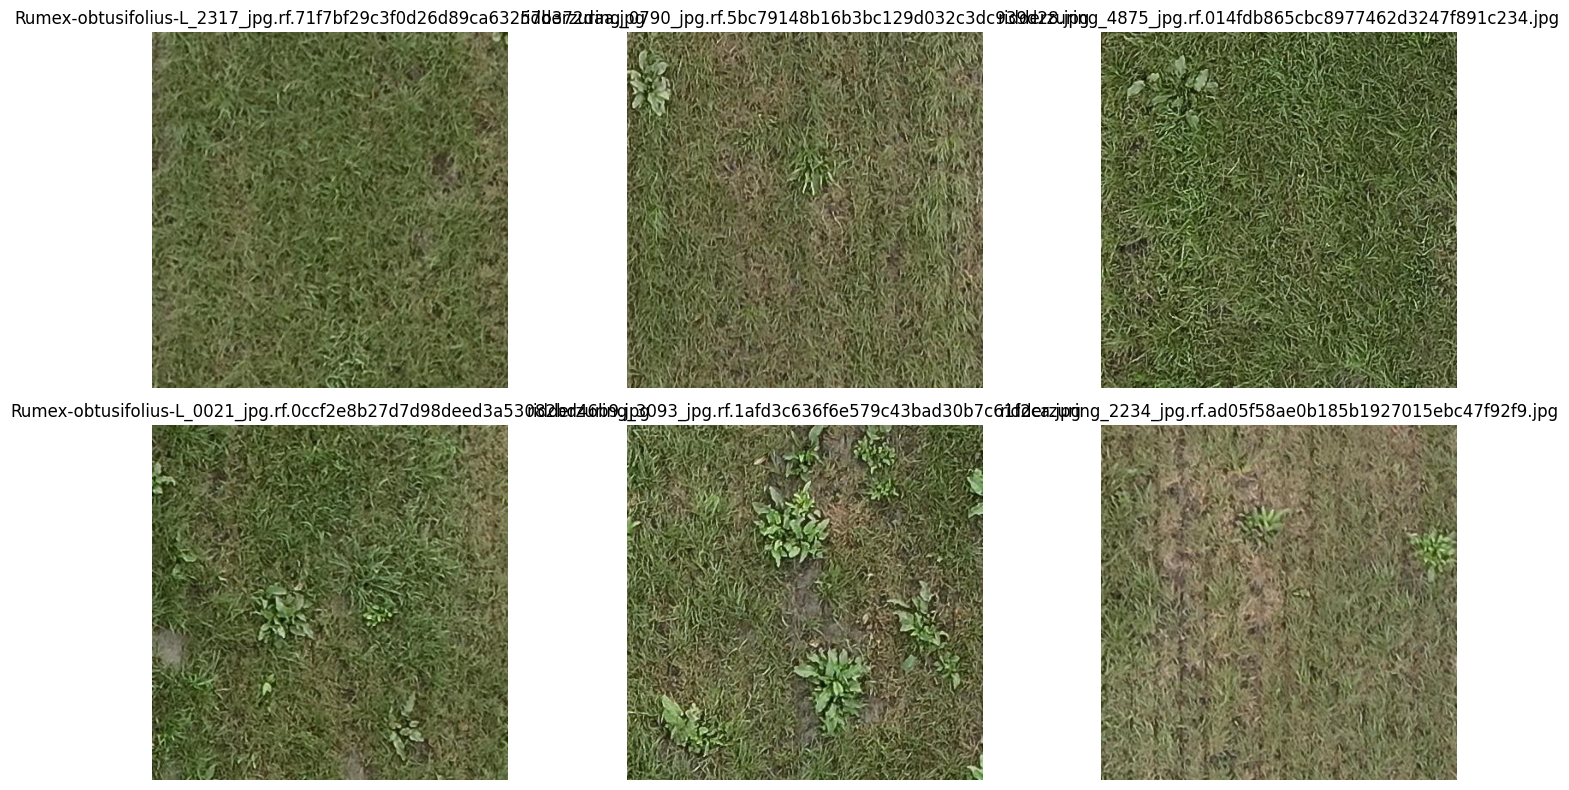

In [ ]:
def show_sample_images(dataset_path, split="train", num_images=6):
    base_split_path = os.path.join(dataset_path, split)
    img_subfolder = os.path.join(base_split_path, "images")
    final_path = img_subfolder if os.path.exists(img_subfolder) else base_split_path
    image_files = [
        os.path.join(final_path, f)
        for f in os.listdir(final_path)
        if f.lower().endswith(('.png', '.jpg', '.jpeg'))
    ]

    sample_images = random.sample(
        image_files,
        min(num_images, len(image_files))
    )

    plt.figure(figsize=(15, 8))
    for i, img_path in enumerate(sample_images):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(2, 3, i + 1)
        plt.imshow(img)
        plt.title(os.path.basename(img_path))
        plt.axis("off")

    plt.tight_layout()
    plt.show()
show_sample_images(dataset_path)


# **Pre-Processing**

Tujuannya untuk menyiapkan citra agar lebih siap untuk proses ekstraksi fitur. Tahap ini terdiri dari pembacaan label YOLO, cropping ROI gulma dan background, resize, Gaussian Blur, serta konversi warna.

## Membaca Label YOLO

Membaca file anotasi YOLO yang berisi class, titik tengah bounding box, lebar, dan tinggi objek gulma. Tujuannya adalah mengetahui lokasi gulma pada gambar sehingga area gulma dapat diambil secara otomatis.

In [ ]:
def read_yolo_label(label_path):
    boxes = []
    # cek apakah file label ada
    if not os.path.exists(label_path):
        return boxes

    with open(label_path, "r") as f:
        lines = f.readlines()
        for line in lines:
            data = line.strip().split()

            # format YOLO = 5 nilai
            if len(data) != 5:
                continue
            cls, x, y, w, h = map(float, data)

            boxes.append({
                "class": int(cls),
                "x": x,
                "y": y,
                "w": w,
                "h": h
            })

    return boxes

## Crop ROI dari Bounding Box

Setelah koordinat bounding box diperoleh, area gulma dipotong menggunakan proses cropping. Tujuannya agar model fokus mempelajari objek gulma tanpa terganggu area rumput yang tidak relevan.

In [ ]:
def crop_bbox(image, bbox):

    H, W = image.shape[:2]

    # koordinat tengah bbox
    x_center = bbox["x"] * W
    y_center = bbox["y"] * H

    # ukuran bbox
    bw = bbox["w"] * W
    bh = bbox["h"] * H

    # sudut bbox
    x1 = int(x_center - bw / 2)
    y1 = int(y_center - bh / 2)

    x2 = int(x_center + bw / 2)
    y2 = int(y_center + bh / 2)

    # supaya tidak keluar gambar
    x1 = max(0, x1)
    y1 = max(0, y1)

    x2 = min(W, x2)
    y2 = min(H, y2)

    crop = image[y1:y2, x1:x2]

    return crop

## Random Background Patch

membuat kelas background dengan mengambil area rumput yang tidak beririsan dengan bounding box gulma. Tujuannya agar model dapat belajar membedakan karakteristik gulma dan rumput biasa.

In [ ]:
def crop_background(image, boxes, size=128):

    H, W = image.shape[:2]

    if H < size or W < size:
        return None

    # coba random 20x
    for _ in range(20):

        x = random.randint(0, W-size)
        y = random.randint(0, H-size)

        x2 = x + size
        y2 = y + size

        overlap = False

        # hindari overlap dengan bbox gulma
        for bbox in boxes:

            bx = bbox["x"] * W
            by = bbox["y"] * H

            bw = bbox["w"] * W
            bh = bbox["h"] * H

            bx1 = int(bx - bw/2)
            by1 = int(by - bh/2)

            bx2 = int(bx + bw/2)
            by2 = int(by + bh/2)

            # cek overlap
            if not (x2 < bx1 or x > bx2 or y2 < by1 or y > by2):
                overlap = True
                break

        if not overlap:

            crop = image[y:y2, x:x2]

            return crop

    return None

Resize Image

In [ ]:
def resize_image(image, size = 128):
    resized = cv2.resize(image, (size, size), interpolation=cv2.INTER_AREA)
    return resized

Gaussian Blur

Mengurangi noise sehingga fitur yang diekstraksi menjadi lebih stabil.

In [ ]:
def apply_gaussian_blur(image):
    blurred = cv2.GaussianBlur(image, (3,3), 0)
    return blurred

Konversi RGB ke HSV

In [ ]:
def convert_rgb_to_hsv(image):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    return hsv

Konversi RGB ke Grayscale

In [ ]:
def convert_rgb_to_grayscale(image):
    grayscale = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return grayscale

## Simpan Pre processing

In [ ]:
records = []

IMG_SIZE = 128

for split in ["train", "valid", "test"]:

    print(f"\nProcessing split: {split}")

    base_split_path = os.path.join(dataset_path, split)
    img_dir_candidate = os.path.join(base_split_path, "images")
    img_dir = img_dir_candidate if os.path.exists(img_dir_candidate) else base_split_path

    lbl_dir_candidate = os.path.join(base_split_path, "labels")
    lbl_dir = lbl_dir_candidate if os.path.exists(lbl_dir_candidate) else base_split_path

    image_files = os.listdir(img_dir)

    for img_file in image_files:

        if not img_file.lower().endswith((".jpg", ".png", ".jpeg")):
            continue

        image_path = os.path.join(img_dir, img_file)

        image = cv2.imread(image_path)

        if image is None:
            continue

        stem = Path(img_file).stem

        label_path = os.path.join(lbl_dir, stem + ".txt")

        # BACA BBOX GULMA
        boxes = read_yolo_label(label_path)

        # ROI GULMA (LABEL = 1)
        for bbox in boxes:

            crop = crop_bbox(image, bbox)

            if crop.size == 0:
                continue

            # preprocessing
            resized = resize_image(crop, IMG_SIZE)
            blurred = apply_gaussian_blur(resized)
            hsv = convert_rgb_to_hsv(blurred)
            gray = convert_rgb_to_grayscale(blurred)


            records.append({
                "split": split,
                "filename": img_file,
                "label": 1,
                "class_name": "weed",
                "original": crop,
                "resized": resized,
                "blurred": blurred,
                "hsv": hsv,
                "gray": gray
            })

        # BACKGROUND PATCH (LABEL = 0)
        bg_crop = crop_background(
            image,
            boxes,
            size=IMG_SIZE
        )

        if bg_crop is not None:
            resized = resize_image(bg_crop, IMG_SIZE)
            blurred = apply_gaussian_blur(resized)
            hsv = convert_rgb_to_hsv(blurred)
            gray = convert_rgb_to_grayscale(blurred)
            records.append({
                "split": split,
                "filename": img_file,
                "label": 0,
                "class_name": "background",
                "original": bg_crop,
                "resized": resized,
                "blurred": blurred,
                "hsv": hsv,
                "gray": gray
            })

df = pd.DataFrame(records)

print("\n===== DATASET INFO =====")

print(df[[
    "split",
    "filename",
    "label",
    "class_name"
]].head())

print(f"\nTotal ROI : {len(df)}")

print("\nDistribusi Label:")

print(df["class_name"].value_counts())


Processing split: train

Processing split: valid

Processing split: test

===== DATASET INFO =====
   split                                           filename  label  class_name
0  train  Rumex-obtusifolius-L_2514_jpg.rf.e1e6f16acc77d...      1        weed
1  train  Rumex-obtusifolius-L_2514_jpg.rf.e1e6f16acc77d...      1        weed
2  train  Rumex-obtusifolius-L_2514_jpg.rf.e1e6f16acc77d...      0  background
3  train  Rumex-obtusifolius-L_2517_jpg.rf.7cbc451f0d223...      1        weed
4  train  Rumex-obtusifolius-L_2517_jpg.rf.7cbc451f0d223...      1        weed

Total ROI : 9214

Distribusi Label:
class_name
weed          6799
background    2415
Name: count, dtype: int64


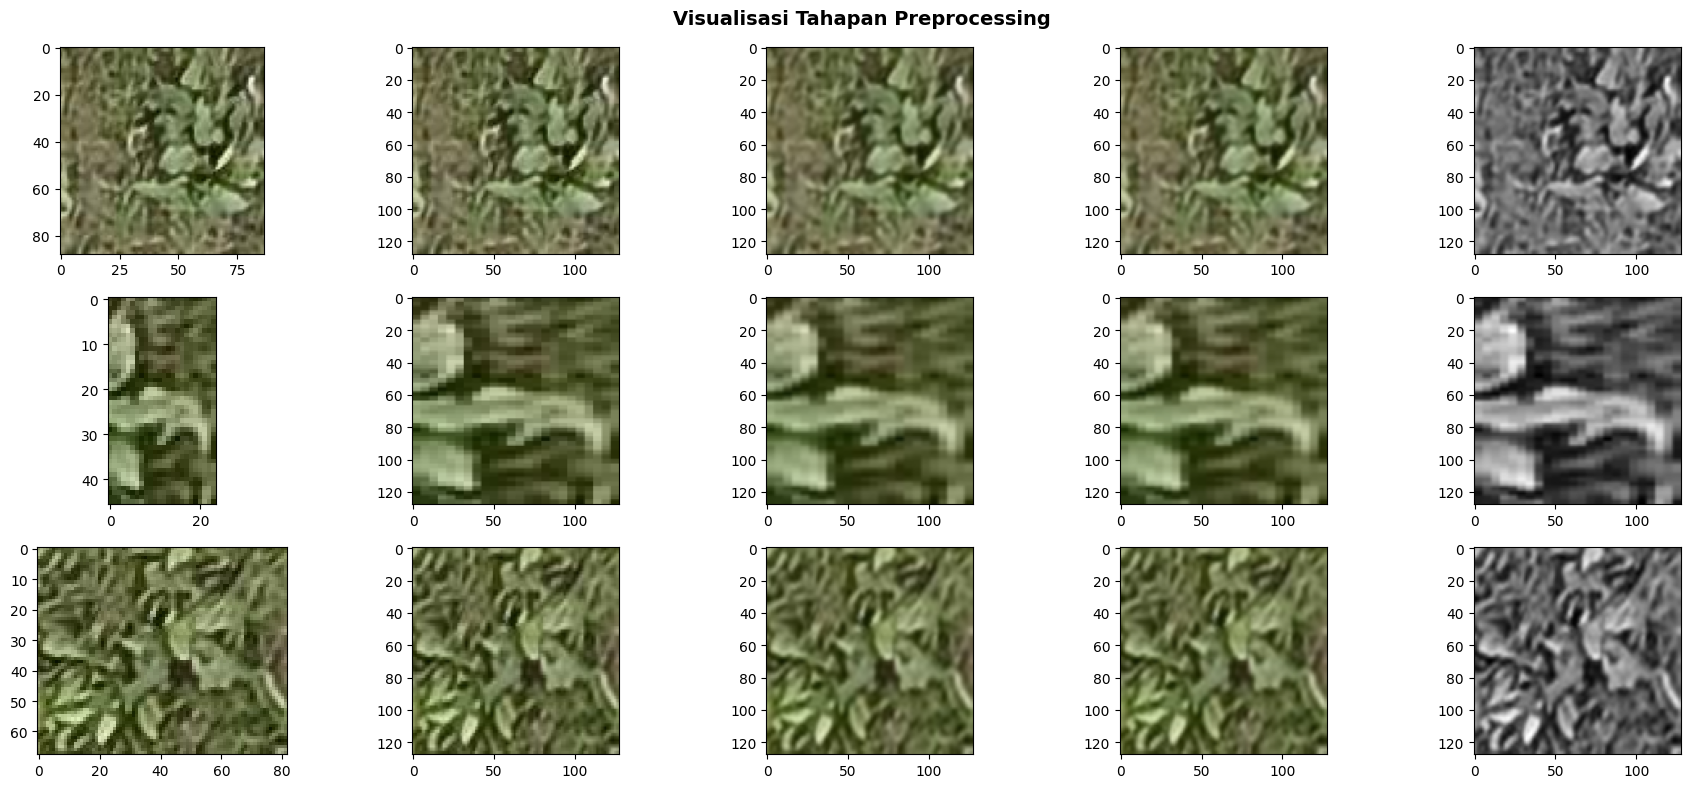

In [ ]:
samples = df.sample(3).reset_index(drop=True)

stages = [
    "original",
    "resized",
    "blurred",
    "hsv",
    "gray"
]

titles = [
    "Original",
    "Resize 128x128",
    "Gaussian Blur",
    "HSV",
    "Grayscale"
]

fig, axes = plt.subplots(
    3,
    5,
    figsize=(18, 8)
)

for row, (_, r) in enumerate(samples.iterrows()):
    for col, (stage, title) in enumerate(zip(stages, titles)):
        ax = axes[row, col]
        img = r[stage]
        # BGR
        if stage in ["original", "resized", "blurred"]:

            ax.imshow(
                cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            )

        # HSV
        elif stage == "hsv":
            hsv_rgb = cv2.cvtColor(
                img,
                cv2.COLOR_HSV2RGB
            )

            ax.imshow(hsv_rgb)

        # grayscale
        elif stage == "gray":

            ax.imshow(
                img,
                cmap="gray"
            )

plt.suptitle(
    "Visualisasi Tahapan Preprocessing",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

# **Ekstraksi Fitur**

## HOG (Bentuk)

In [ ]:
def extract_hog_features(
    gray,
    orientations=9,
    pixels_per_cell=(8,8),
    cells_per_block=(2,2)
):

    feat, hog_img = hog(
        gray,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block,
        visualize=True
    )

    return feat, hog_img

sample = samples.iloc[1]

hog_feat, hog_img = extract_hog_features(sample["gray"])

print(f"Panjang fitur HOG : {len(hog_feat)}")

Panjang fitur HOG : 8100


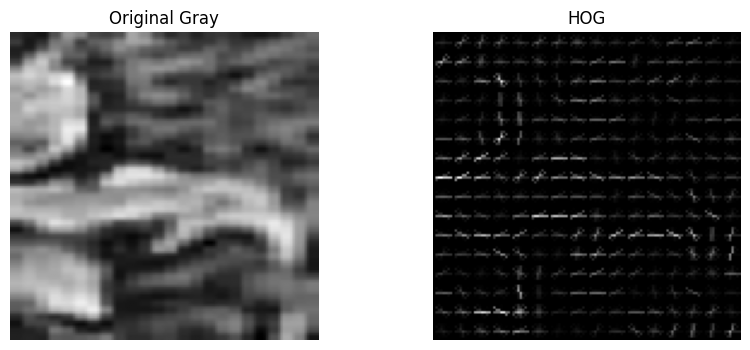

In [ ]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(sample["gray"], cmap="gray")
plt.title("Original Gray")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(hog_img, cmap="gray")
plt.title("HOG")
plt.axis("off")

plt.show()

## HSV (Warna)

In [ ]:
def extract_hsv_features(hsv_img, mode="mean_std"):

    h, s, v = cv2.split(hsv_img)

    if mode == "mean":

        features = [
            np.mean(h),
            np.mean(s),
            np.mean(v)
        ]

    elif mode == "std":

        features = [
            np.std(h),
            np.std(s),
            np.std(v)
        ]

    elif mode == "mean_std":

        features = [

            np.mean(h),
            np.std(h),

            np.mean(s),
            np.std(s),

            np.mean(v),
            np.std(v)
        ]

    return np.array(features)

sample_hsv_feat = extract_hsv_features(sample["hsv"], mode="mean_std")

print(f"Panjang fitur HSV : {len(sample_hsv_feat)}")

Panjang fitur HSV : 6


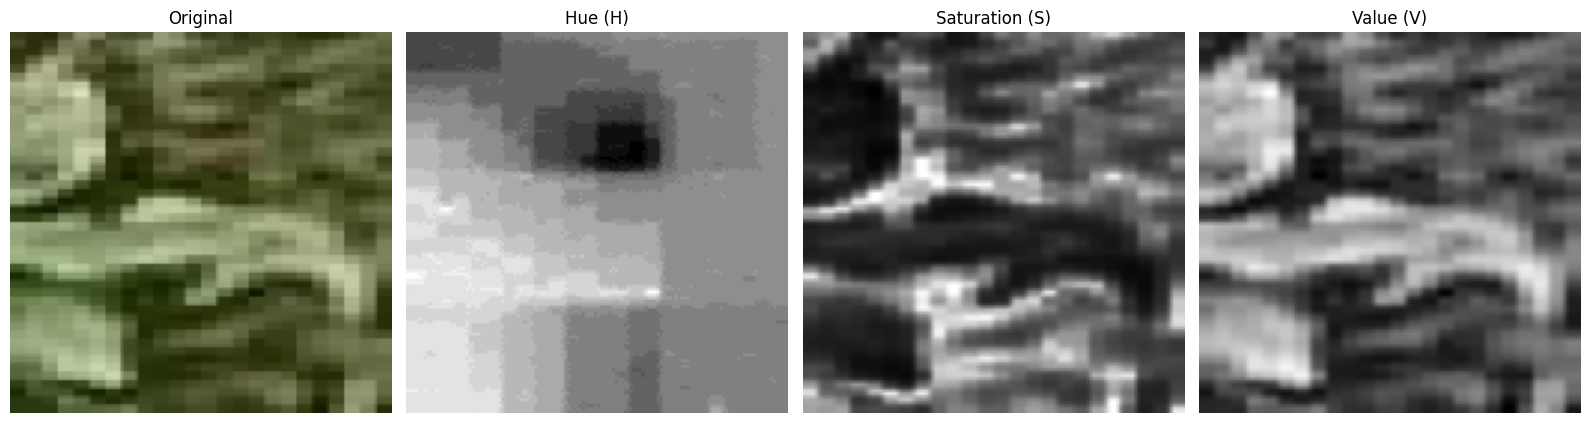

In [ ]:
sample_hsv = sample["hsv"]

h, s, v = cv2.split(sample_hsv)

plt.figure(figsize=(16, 5))

# ORIGINAL
plt.subplot(1, 4, 1)
plt.imshow(cv2.cvtColor(sample["resized"], cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

# H
plt.subplot(1, 4, 2)
plt.imshow(h, cmap="gray")
plt.title("Hue (H)")
plt.axis("off")

# S
plt.subplot(1, 4, 3)
plt.imshow(s, cmap="gray")
plt.title("Saturation (S)")
plt.axis("off")

# V
plt.subplot(1, 4, 4)
plt.imshow(v, cmap="gray")
plt.title("Value (V)")
plt.axis("off")

plt.tight_layout()
plt.show()

## GLCM (Tekstur)

In [ ]:
def quantize_image(image, levels):

    quantized = np.floor(
        image / (256 / levels)
    ).astype(np.uint8)

    quantized[quantized >= levels] = levels - 1

    return quantized

In [ ]:
def extract_glcm_features(gray_quantized, distance=1, levels=16):
    glcm = graycomatrix(
        gray_quantized,
        distances=[distance],
        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
        levels=levels,
        symmetric=True,
        normed=True
    )
    contrast    = graycoprops(glcm, 'contrast').mean()
    correlation = graycoprops(glcm, 'correlation').mean()
    energy      = graycoprops(glcm, 'energy').mean()
    homogeneity = graycoprops(glcm, 'homogeneity').mean()

    return np.array([contrast, correlation, energy, homogeneity])

In [ ]:
gray = sample["gray"]

# quantization
levels = 16

gray_quantized = quantize_image(
    gray,
    levels=levels
)

# ekstraksi fitur
glcm_features = extract_glcm_features(
    gray_quantized,
    distance=1,
    levels=levels
)

print("GLCM Features:")
print(f"Contrast   : {glcm_features[0]:.4f}")
print(f"Correlation: {glcm_features[1]:.4f}")
print(f"Energy     : {glcm_features[2]:.4f}")
print(f"Homogeneity: {glcm_features[3]:.4f}")

GLCM Features:
Contrast   : 0.5191
Correlation: 0.9619
Energy     : 0.2337
Homogeneity: 0.8087


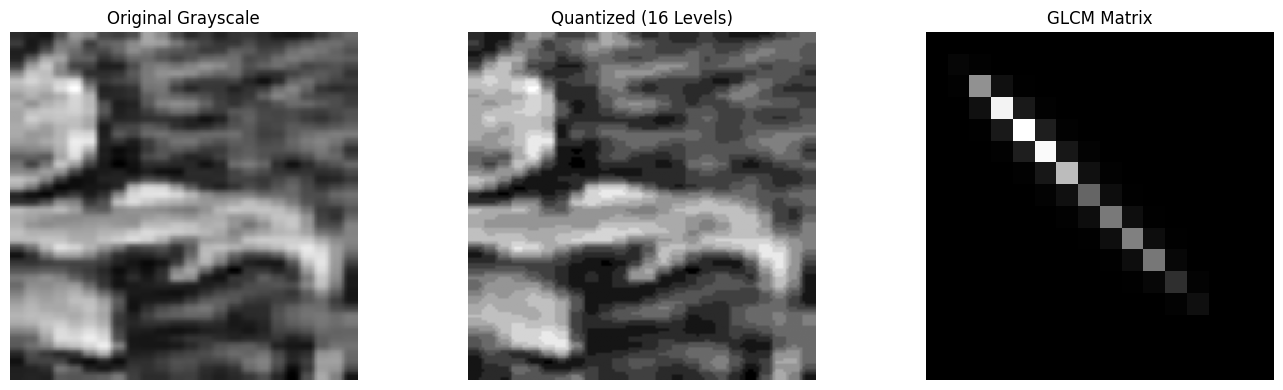

In [ ]:
# bangun matriks GLCM
glcm = graycomatrix(
    gray_quantized,
    distances=[1],
    angles=[0],
    levels=levels,
    symmetric=True,
    normed=True
)

plt.figure(figsize=(14,4))

plt.subplot(1,3,1)
plt.imshow(gray, cmap="gray")
plt.title("Original Grayscale")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(gray_quantized, cmap="gray")
plt.title(f"Quantized ({levels} Levels)")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(glcm[:, :, 0, 0], cmap="gray")
plt.title("GLCM Matrix")
plt.axis("off")

plt.tight_layout()
plt.show()

# **Split Data**

In [ ]:
train_df = df[df["split"] == "train"]
valid_df = df[df["split"] == "valid"]
test_df  = df[df["split"] == "test"]

# **Uji Eksperimen Parameter**

mencari parameter terbaik untuk masing-masing metode ekstraksi fitur.

## HOG (Bentuk)

Parameter yang diuji dipilih berdasarkan konfigurasi yang umum digunakan pada ekstraksi fitur HOG serta mempertimbangkan ukuran citra yang digunakan dalam penelitian, yaitu 128 × 128 piksel. Pengujian difokuskan pada parameter yang paling berpengaruh terhadap kualitas fitur, yaitu orientations dan pixels_per_cell.

In [ ]:
hog_results = []

# kombinasi parameter HOG yang diuji
# Ukuran (8,8) dipilih karena mampu menangkap detail bentuk yang lebih halus
hog_params = [
    {"orientations": 9,  "pixels_per_cell": (8,8),   "cells_per_block": (2,2)},
    {"orientations": 9,  "pixels_per_cell": (16,16),  "cells_per_block": (2,2)},
    {"orientations": 12, "pixels_per_cell": (8,8),   "cells_per_block": (2,2)},
    {"orientations": 12, "pixels_per_cell": (16,16),  "cells_per_block": (2,2)},
]

for params in hog_params:
    print(f"\nTesting HOG params: {params}")

    # EKSTRAKSI FITUR TRAIN
    X_train = np.array([
        extract_hog_features(
            gray=x,
            orientations=params["orientations"],
            pixels_per_cell=params["pixels_per_cell"],
            cells_per_block=params["cells_per_block"]
        )[0]
        for x in train_df["gray"]
    ])

    # EKSTRAKSI FITUR VALID
    X_valid = np.array([

        extract_hog_features(
            gray=x,
            orientations=params["orientations"],
            pixels_per_cell=params["pixels_per_cell"],
            cells_per_block=params["cells_per_block"]
        )[0]

        for x in valid_df["gray"]

    ])

    # LABEL
    y_train = train_df["label"].values
    y_valid = valid_df["label"].values

    # NORMALISASI
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_valid = scaler.transform(X_valid)

    # TRAINING SVM
    svm = SVC(kernel="rbf", class_weight="balanced")
    svm.fit(X_train, y_train)
    pred = svm.predict(X_valid)

    acc = accuracy_score(y_valid, pred)
    f1  = f1_score(y_valid, pred, average="macro")

    hog_results.append({
        "orientations"    : params["orientations"],
        "pixels_per_cell" : str(params["pixels_per_cell"]),
        "cells_per_block" : str(params["cells_per_block"]),
        "accuracy"        : round(acc, 4),
        "macro_f1"        : round(f1,  4)
    })

hog_results = pd.DataFrame(hog_results).sort_values("macro_f1", ascending=False)
display(hog_results)

best_hog_row = hog_results.iloc[0]
print(f"\nParameter HOG terbaik:")
print(f"  orientations    = {best_hog_row['orientations']}")
print(f"  pixels_per_cell = {best_hog_row['pixels_per_cell']}")
print(f"  cells_per_block = {best_hog_row['cells_per_block']}")
print(f"  Accuracy        : {best_hog_row['accuracy']:.4f}")
print(f"  Macro F1        : {best_hog_row['macro_f1']:.4f}")


Testing HOG params: {'orientations': 9, 'pixels_per_cell': (8, 8), 'cells_per_block': (2, 2)}

Testing HOG params: {'orientations': 9, 'pixels_per_cell': (16, 16), 'cells_per_block': (2, 2)}

Testing HOG params: {'orientations': 12, 'pixels_per_cell': (8, 8), 'cells_per_block': (2, 2)}

Testing HOG params: {'orientations': 12, 'pixels_per_cell': (16, 16), 'cells_per_block': (2, 2)}


,orientations,pixels_per_cell,cells_per_block,accuracy,macro_f1
0,9,"(8, 8)","(2, 2)",0.9928,0.9896
1,9,"(16, 16)","(2, 2)",0.9912,0.9873
2,12,"(8, 8)","(2, 2)",0.9912,0.9873
3,12,"(16, 16)","(2, 2)",0.9896,0.9850



Parameter HOG terbaik:
  orientations    = 9
  pixels_per_cell = (8, 8)
  cells_per_block = (2, 2)
  Accuracy        : 0.9928
  Macro F1        : 0.9896


Ukuran cell yang lebih kecil mampu menangkap detail bentuk dan tepi daun dengan lebih baik.

## HSV (Warna)

Pada fitur HSV, tujuan penelitian bukan mencari kombinasi parameter seperti pada HOG, tetapi mencari representasi warna yang paling baik untuk membedakan gulma dan background. Oleh karena itu, dilakukan pengujian terhadap tiga metode ekstraksi statistik yang sederhana namun sering digunakan, yaitu mean, std, dan mean_std.

In [ ]:
from sklearn.metrics import f1_score
hsv_results = []

# parameter yang diuji
hsv_modes = [
    "mean",
    "std",
    "mean_std"
]

for mode in hsv_modes:

    print(f"Testing HSV mode: {mode}")

    X_train = np.array([
        extract_hsv_features(x, mode)
        for x in train_df["hsv"]
    ])

    X_valid = np.array([
        extract_hsv_features(x, mode)
        for x in valid_df["hsv"]
    ])

    # label
    y_train = train_df["label"].values
    y_valid = valid_df["label"].values

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_valid = scaler.transform(X_valid)

    svm = SVC(kernel="rbf", class_weight="balanced")
    svm.fit(X_train, y_train)
    pred = svm.predict(X_valid)

    acc = accuracy_score(y_valid, pred)
    f1  = f1_score(y_valid, pred, average="macro")

    hsv_results.append({
        "mode"    : mode,
        "accuracy": round(acc, 4),
        "macro_f1": round(f1,  4)
    })

hsv_results = pd.DataFrame(hsv_results).sort_values("macro_f1", ascending=False)
display(hsv_results)

best_hsv = hsv_results.iloc[0]
print(f"\nParameter HSV terbaik : mode = {best_hsv['mode']}")
print(f"Accuracy  : {best_hsv['accuracy']:.4f}")
print(f"Macro F1  : {best_hsv['macro_f1']:.4f}")

Testing HSV mode: mean
Testing HSV mode: std
Testing HSV mode: mean_std


,mode,accuracy,macro_f1
2,mean_std,0.9675,0.9545
1,std,0.9602,0.9449
0,mean,0.7738,0.7194



Parameter HSV terbaik : mode = mean_std
Accuracy  : 0.9675
Macro F1  : 0.9545


Mode mean_std memberikan hasil terbaik karena memanfaatkan rata-rata warna dan variasi warna sekaligus. Mean menggambarkan warna dominan, sedangkan std menggambarkan variasi warna pada objek.

## GLCM

Pada fitur GLCM, parameter yang diuji adalah distance karena parameter ini secara langsung memengaruhi hubungan tekstur antar piksel. Sementara itu, nilai levels dibuat tetap sebesar 16 agar pengaruh perubahan performa benar-benar berasal dari perbedaan nilai distance.

In [ ]:
glcm_results = []

glcm_params = [
    {"distance": 1, "levels": 16},
    {"distance": 2, "levels": 16},
    {"distance": 3, "levels": 16},
]

for params in glcm_params:
    print(f"\nTesting GLCM params: {params}")

    # TRAIN FEATURE
    X_train = []
    for gray in train_df["gray"]:
        gray_q = quantize_image(gray, levels=params["levels"])
        feat   = extract_glcm_features(gray_q,
                                        distance=params["distance"],
                                        levels=params["levels"])
        X_train.append(feat)
    X_train = np.array(X_train)

    # VALID FEATURE
    X_valid = []
    for gray in valid_df["gray"]:
        gray_q = quantize_image(gray, levels=params["levels"])
        feat   = extract_glcm_features(gray_q,
                                        distance=params["distance"],
                                        levels=params["levels"])
        X_valid.append(feat)
    X_valid = np.array(X_valid)

    # LABEL
    y_train = train_df["label"].values
    y_valid = valid_df["label"].values

    # NORMALISASI
    scaler  = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_valid = scaler.transform(X_valid)

    # SVM
    svm = SVC(kernel="rbf", class_weight="balanced")
    svm.fit(X_train, y_train)
    pred = svm.predict(X_valid)

    acc = accuracy_score(y_valid, pred)
    f1  = f1_score(y_valid, pred, average="macro")

    glcm_results.append({
        "distance": params["distance"],
        "levels"  : params["levels"],
        "accuracy": round(acc, 4),
        "macro_f1": round(f1,  4)
    })

glcm_results = pd.DataFrame(glcm_results).sort_values("macro_f1", ascending=False)
display(glcm_results)

best_glcm_row = glcm_results.iloc[0]
print(f"\nParameter GLCM terbaik:")
print(f"  distance  = {best_glcm_row['distance']}")
print(f"  Accuracy  : {best_glcm_row['accuracy']:.4f}")
print(f"  Macro F1  : {best_glcm_row['macro_f1']:.4f}")


Testing GLCM params: {'distance': 1, 'levels': 16}

Testing GLCM params: {'distance': 2, 'levels': 16}

Testing GLCM params: {'distance': 3, 'levels': 16}


,distance,levels,accuracy,macro_f1
1,2,16,0.9964,0.9947
2,3,16,0.9956,0.9936
0,1,16,0.9952,0.9930



Parameter GLCM terbaik:
  distance  = 2.0
  Accuracy  : 0.9964
  Macro F1  : 0.9947


Distance 2 menghasilkan performa terbaik karena mampu menangkap hubungan tekstur antar piksel secara lebih optimal.

# **Penggabungan Fitur**

## Feature Fusion

Setelah diperoleh parameter terbaik dari HSV, GLCM, dan HOG, langkah berikutnya adalah melakukan feature fusion menggunakan metode feature concatenation. Metode ini dilakukan dengan menggabungkan seluruh vektor fitur hasil ekstraksi menjadi satu vektor fitur baru.

In [ ]:
# parameter terbaik hasil eksperimen
BEST_HSV_MODE = "mean_std"

BEST_HOG = {
    "orientations": 9,
    "pixels_per_cell": (8,8),
    "cells_per_block": (2,2)
}

BEST_GLCM = {
    "distance": 2,
    "levels": 16
}

# FEATURE FUSION - TRAIN
X_train = []

for idx in train_df.index:
    # HSV FEATURE
    # Bagian ini mengekstraksi fitur warna HSV menggunakan mode mean_std.
    hsv_feat = extract_hsv_features(
        train_df.loc[idx, "hsv"],
        mode=BEST_HSV_MODE
    )

    # GLCM FEATURE
    gray = train_df.loc[idx, "gray"]
    gray_q = quantize_image(
        gray,
        levels=BEST_GLCM["levels"]
    )
     # Bagian ini menghasilkan fitur tekstur berupa contrast, correlation, energy, dan homogeneity.
    glcm_feat = extract_glcm_features(
        gray_q,
        distance=BEST_GLCM["distance"],
        levels=BEST_GLCM["levels"]
    )

    # HOG FEATURE
    # Bagian ini menghasilkan fitur bentuk berdasarkan distribusi gradien
    hog_feat, _ = extract_hog_features(
        gray,
        orientations=BEST_HOG["orientations"],
        pixels_per_cell=BEST_HOG["pixels_per_cell"],
        cells_per_block=BEST_HOG["cells_per_block"]
    )

    # FEATURE CONCATENATION
    fusion_feat = np.concatenate([
        hsv_feat,
        glcm_feat,
        hog_feat
    ])
    X_train.append(fusion_feat)
X_train = np.array(X_train)

# FEATURE FUSION - VALID
X_valid = []

for idx in valid_df.index:
    # HSV FEATURE
    hsv_feat = extract_hsv_features(
        valid_df.loc[idx, "hsv"],
        mode=BEST_HSV_MODE
    )

    # GLCM FEATURE
    gray = valid_df.loc[idx, "gray"]

    gray_q = quantize_image(
        gray,
        levels=BEST_GLCM["levels"]
    )

    glcm_feat = extract_glcm_features(
        gray_q,
        distance=BEST_GLCM["distance"],
        levels=BEST_GLCM["levels"]
    )

    # HOG FEATURE
    hog_feat, _ = extract_hog_features(
        gray,
        orientations=BEST_HOG["orientations"],
        pixels_per_cell=BEST_HOG["pixels_per_cell"],
        cells_per_block=BEST_HOG["cells_per_block"]
    )

    # FEATURE CONCATENATION
    fusion_feat = np.concatenate([
        hsv_feat,
        glcm_feat,
        hog_feat
    ])
    X_valid.append(fusion_feat)
X_valid = np.array(X_valid)

# LABEL
y_train = train_df["label"].values
y_valid = valid_df["label"].values

# CEK DIMENSI FITUR
print("Shape X_train :", X_train.shape)
print("Shape X_valid :", X_valid.shape)

print("\nJumlah fitur gabungan :", X_train.shape[1])

Shape X_train : (5825, 8110)
Shape X_valid : (2489, 8110)

Jumlah fitur gabungan : 8110


## Standardization

Setelah fitur HSV, GLCM, dan HOG digabungkan, diperoleh 8110 fitur untuk setiap citra. Namun, ketiga metode ekstraksi fitur tersebut menghasilkan rentang nilai yang berbeda-beda sehingga perlu dilakukan standardisasi.

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)

print("\nShape setelah normalisasi")
print("X_train_scaled :", X_train_scaled.shape)
print("X_valid_scaled :", X_valid_scaled.shape)


Shape setelah normalisasi
X_train_scaled : (5825, 8110)
X_valid_scaled : (2489, 8110)


Fungsi fit_transform digunakan pada data training untuk menghitung rata-rata dan standar deviasi setiap fitur, kemudian seluruh fitur diubah agar memiliki rata-rata mendekati 0 dan standar deviasi mendekati 1.

Sedangkan data validation hanya menggunakan transform agar mengikuti skala yang diperoleh dari data training.

Hasil standardisasi tidak mengubah jumlah fitur maupun jumlah data. Yang berubah hanya skala nilainya.

## PCA (dimension reduction)

memiliki 8110 fitur untuk setiap citra. Jumlah fitur yang sangat besar dapat meningkatkan waktu komputasi dan menyebabkan redundansi informasi.

Oleh karena itu digunakan PCA untuk mereduksi jumlah fitur tanpa kehilangan sebagian besar informasi penting.

Komponen untuk 90% variance : 1199
Komponen untuk 95% variance : 1598


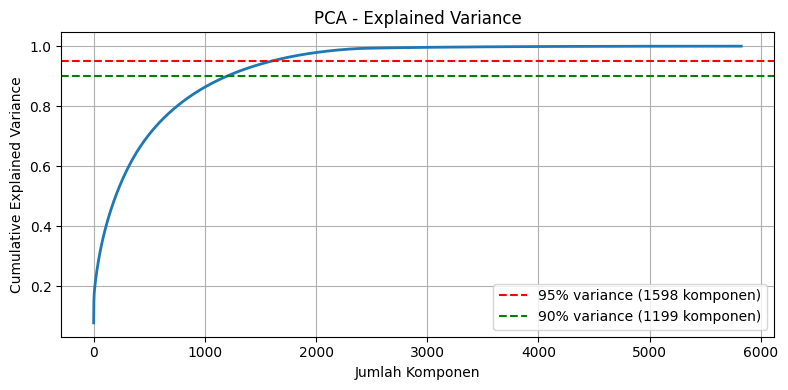

In [ ]:
# cek dulu komponen yang dibutuhkan untuk 90% dan 95%
pca_check = PCA()
pca_check.fit(X_train_scaled)

cumvar = np.cumsum(pca_check.explained_variance_ratio_)
n_90   = np.argmax(cumvar >= 0.90) + 1
n_95   = np.argmax(cumvar >= 0.95) + 1

print(f"Komponen untuk 90%   variance : {n_90}")
print(f"Komponen untuk 95% variance : {n_95}")

# visualisasi explained variance
plt.figure(figsize=(8, 4))
plt.plot(cumvar, linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--', label=f'95% variance ({n_95} komponen)')
plt.axhline(y=0.90, color='g', linestyle='--', label=f'90% variance ({n_90} komponen)')
plt.xlabel("Jumlah Komponen")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Explained Variance")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Grafik ini menunjukkan hubungan antara jumlah komponen PCA dan cumulative explained variance. Sumbu X menunjukkan jumlah komponen PCA, sedangkan sumbu Y menunjukkan akumulasi informasi yang berhasil dipertahankan. Semakin ke kanan, semakin banyak informasi yang dipertahankan.

memilih 1199 komponen karena sudah mampu mempertahankan sekitar 90% variasi data dengan jumlah fitur yang jauh lebih sedikit dibandingkan 8110 fitur awal.

In [ ]:
# pilih n_components berdasarkan hasil di atas
N_COMPONENTS = n_90

pca = PCA(n_components=N_COMPONENTS)
X_train_pca = pca.fit_transform(X_train_scaled)
X_valid_pca = pca.transform(X_valid_scaled)

print(f"\nMenggunakan {N_COMPONENTS} komponen PCA")
print(f"Variance tertangkap : {pca.explained_variance_ratio_.sum():.4f}")
print(f"Shape X_train_pca   : {X_train_pca.shape}")
print(f"Shape X_valid_pca   : {X_valid_pca.shape}")


Menggunakan 1199 komponen PCA
Variance tertangkap : 0.8979
Shape X_train_pca   : (5825, 1199)
Shape X_valid_pca   : (2489, 1199)


terjadi pengurangan dimensi sekitar 85,22%. Meskipun jumlah fitur berkurang drastis, PCA masih mampu mempertahankan sekitar 89,8% informasi yang terkandung dalam data.

# **SVM FINAL**

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.01, 0.001],
    "kernel": ["rbf", "linear"]
}

svm = SVC(
    class_weight="balanced",
    random_state=42
)

grid_search = GridSearchCV(
    estimator=svm,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

# training
grid_search.fit(X_train_pca, y_train)

print("\nParameter terbaik:")
print(grid_search.best_params_)

print("\nMacro F1 terbaik:")
print(round(grid_search.best_score_, 3))


Parameter terbaik:
{'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}

Macro F1 terbaik:
0.991


In [ ]:
best_params = grid_search.best_params_

best_svm = SVC(
    C=10,
    gamma="scale",
    kernel="rbf",
    class_weight="balanced",
    random_state=42,
    probability=True
)

# TRAIN MODEL FINAL
best_svm.fit(X_train_pca, y_train)

# PREDIKSI
y_pred_valid = best_svm.predict(X_valid_pca)

In [ ]:
print("EVALUASI VALIDATION")

# prediksi validation
y_pred_valid = best_svm.predict(X_valid_pca)

# hitung metric
acc_valid = accuracy_score(y_valid, y_pred_valid)

f1_valid = f1_score(
    y_valid,
    y_pred_valid,
    average="macro"
)

print("Accuracy :", round(acc_valid, 4))
print("Macro F1 :", round(f1_valid, 4))

# classification report
print("\nClassification Report")
print(classification_report(
    y_valid,
    y_pred_valid,
    target_names=["background", "weed"]
))

EVALUASI VALIDATION
Accuracy : 0.9815
Macro F1 : 0.9739

Classification Report
              precision    recall  f1-score   support

  background       0.92      1.00      0.96       550
        weed       1.00      0.98      0.99      1939

    accuracy                           0.98      2489
   macro avg       0.96      0.99      0.97      2489
weighted avg       0.98      0.98      0.98      2489



In [ ]:
X_test_list = []

for idx in test_df.index:

    hsv_feat = extract_hsv_features(test_df.loc[idx, "hsv"], mode=BEST_HSV_MODE)
    gray   = test_df.loc[idx, "gray"]
    gray_q = quantize_image(gray, levels=BEST_GLCM["levels"])
    glcm_feat = extract_glcm_features(gray_q, distance=BEST_GLCM["distance"], levels=BEST_GLCM["levels"])
    hog_feat, _ = extract_hog_features(gray, orientations=BEST_HOG["orientations"], pixels_per_cell=BEST_HOG["pixels_per_cell"], cells_per_block=BEST_HOG["cells_per_block"])
    fusion_feat = np.concatenate([hsv_feat, glcm_feat, hog_feat])
    X_test_list.append(fusion_feat)

X_test = np.array(X_test_list)
y_test = test_df["label"].values

# normalisasi & reduksi dimensi pakai objek yang sudah fit di train
X_test_scaled = scaler.transform(X_test)
X_test_pca    = pca.transform(X_test_scaled)

print(f"Shape X_test     : {X_test.shape}")
print(f"Shape X_test_pca : {X_test_pca.shape}")

Shape X_test     : (900, 8110)
Shape X_test_pca : (900, 1199)


In [ ]:
y_pred_test = best_svm.predict(X_test_pca)

acc_test = accuracy_score(y_test, y_pred_test)
f1_test  = f1_score(y_test, y_pred_test, average="macro")

print(f"Accuracy : {acc_test:.4f}")
print(f"Macro F1 : {f1_test:.4f}")
print()
print(classification_report(
    y_test,
    y_pred_test,
    target_names=["background", "weed"]
))

Accuracy : 0.9589
Macro F1 : 0.9494

              precision    recall  f1-score   support

  background       0.87      1.00      0.93       238
        weed       1.00      0.95      0.97       662

    accuracy                           0.96       900
   macro avg       0.93      0.97      0.95       900
weighted avg       0.96      0.96      0.96       900



# **Confusion Matrix (Visual)**

Membuat Confusion Matrix

In [ ]:
cm_test = confusion_matrix(y_test, y_pred_test)
cm_valid = confusion_matrix(y_valid, y_pred_valid)

print("Confusion Matrix Test:")
print(cm_test)
print()
print("Confusion Matrix Valid:")
print(cm_valid)
print()

Confusion Matrix Test:
[[237   1]
 [ 36 626]]

Confusion Matrix Valid:
[[ 550    0]
 [  46 1893]]



Visualisasi Confusion Matrix

CONFUSION MATRIX


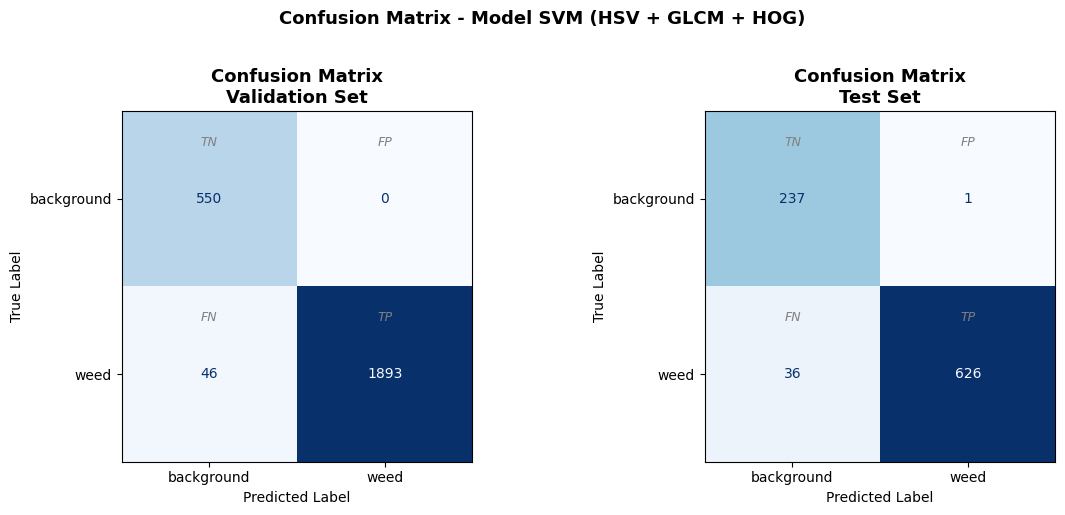


Validation Set:
  TP (weed → weed)   : 1893
  TN (bg   → bg)     : 550
  FP (bg   → weed)   : 0
  FN (weed → bg)     : 46

Test Set:
  TP (weed → weed)   : 626
  TN (bg   → bg)     : 237
  FP (bg   → weed)   : 1
  FN (weed → bg)     : 36


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

print("CONFUSION MATRIX")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

configs = [
    (y_valid, y_pred_valid, "Confusion Matrix\nValidation Set"),
    (y_test,  y_pred_test,  "Confusion Matrix\nTest Set"),
]

for ax, (y_true, y_pred, title) in zip(axes, configs):
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["background", "weed"]
    )
    disp.plot(ax=ax, colorbar=False, cmap="Blues")

    corner_labels = [["TN", "FP"], ["FN", "TP"]]
    for i in range(2):
        for j in range(2):
            ax.text(
                j, i - 0.32,
                corner_labels[i][j],
                ha="center", va="center",
                fontsize=9, color="gray",
                fontstyle="italic"
            )

    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Predicted Label", fontsize=10)
    ax.set_ylabel("True Label", fontsize=10)

plt.suptitle(
    "Confusion Matrix - Model SVM (HSV + GLCM + HOG)",
    fontsize=13, fontweight="bold", y=1.02
)
plt.tight_layout()
plt.show()

for split_name, y_true, y_pred in [
    ("Validation", y_valid, y_pred_valid),
    ("Test",       y_test,  y_pred_test),
]:
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    print(f"\n{split_name} Set:")
    print(f"  TP (weed → weed)   : {tp}")
    print(f"  TN (bg   → bg)     : {tn}")
    print(f"  FP (bg   → weed)   : {fp}")
    print(f"  FN (weed → bg)     : {fn}")

# **Visualisasi Prediksi (Uji Coba Prediksi)**

Ambil Sample Data

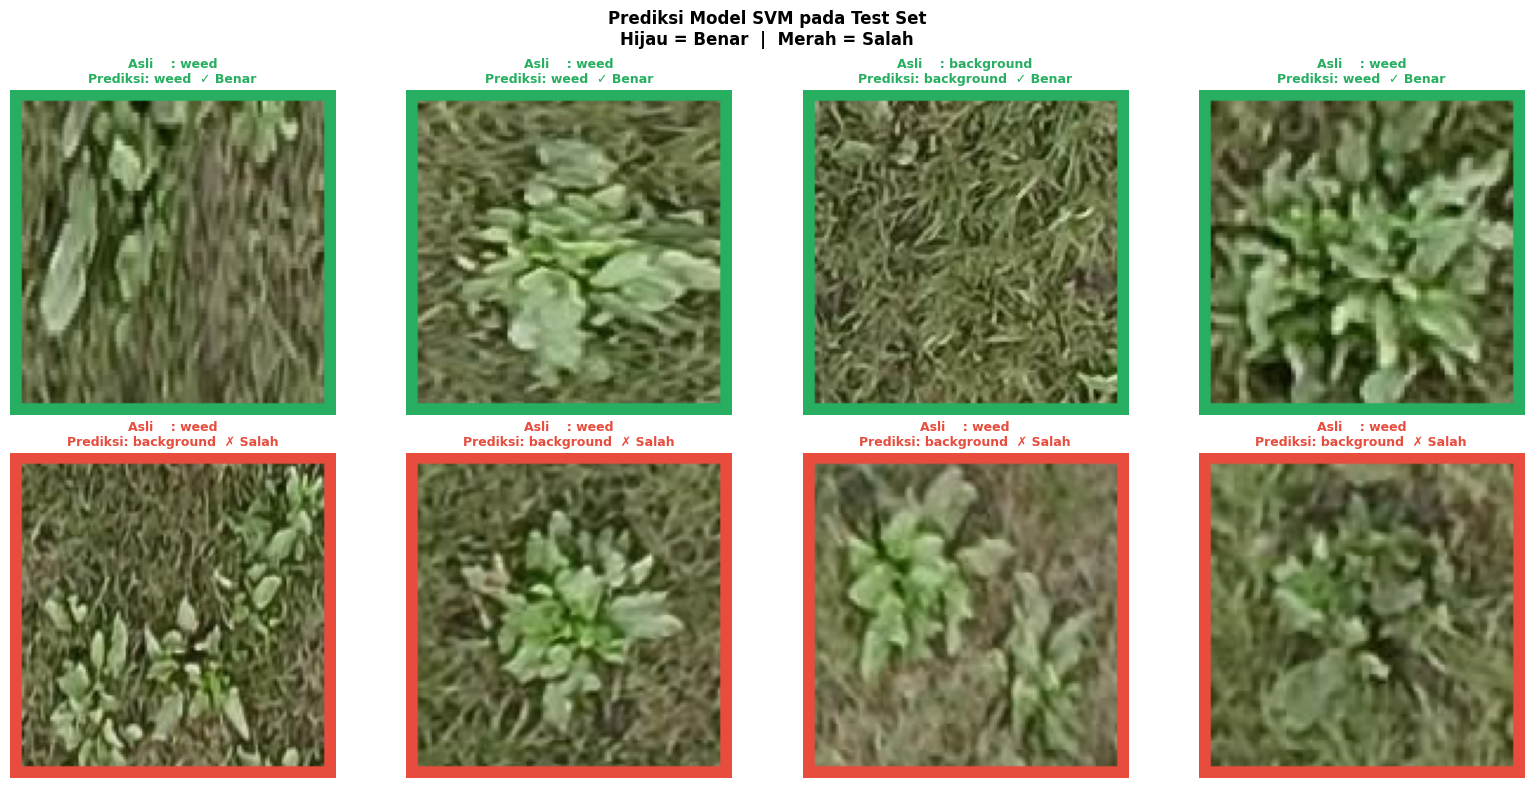

In [ ]:
label_map = {0: "background", 1: "weed"}

test_indices = list(test_df.index)
pred_list    = list(y_pred_test)
true_list    = list(y_test)

correct_idx = [test_indices[i] for i, (p, t)
               in enumerate(zip(pred_list, true_list)) if p == t]
wrong_idx   = [test_indices[i] for i, (p, t)
               in enumerate(zip(pred_list, true_list)) if p != t]

sample_idx  = correct_idx[:4] + wrong_idx[:4]
sample_df   = test_df.loc[sample_idx].reset_index(drop=True)
sample_true = true_list[:4] + [true_list[test_indices.index(i)] for i in wrong_idx[:4]]
sample_pred = pred_list[:4] + [pred_list[test_indices.index(i)] for i in wrong_idx[:4]]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(len(sample_df)):
    ax    = axes[i]
    row   = sample_df.iloc[i]
    true  = sample_true[i]
    pred  = sample_pred[i]

    is_correct   = (true == pred)
    border_color = "#27AE60" if is_correct else "#E74C3C"
    status       = "✓ Benar"  if is_correct else "✗ Salah"

    img_rgb  = cv2.cvtColor(row["resized"], cv2.COLOR_BGR2RGB)
    bordered = cv2.copyMakeBorder(
        img_rgb, 5, 5, 5, 5,
        cv2.BORDER_CONSTANT,
        value=[
            int(border_color[1:3], 16),
            int(border_color[3:5], 16),
            int(border_color[5:7], 16)
        ]
    )

    ax.imshow(bordered)
    ax.set_title(
        f"Asli    : {label_map[true]}\n"
        f"Prediksi: {label_map[pred]}  {status}",
        fontsize=9, color=border_color, fontweight="bold"
    )
    ax.axis("off")

plt.suptitle(
    "Prediksi Model SVM pada Test Set\n"
    "Hijau = Benar  |  Merah = Salah",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()

## Prediksi Sample

Upload citra ROI (crop) yang ingin diuji.
Citra dapat berupa gulma (weed) maupun background.



Saving Gambar 1.1.jpeg to Gambar 1.1.jpeg
Saving Gambar 1.2.jpeg to Gambar 1.2.jpeg
Saving Gambar 2.1.jpeg to Gambar 2.1.jpeg
Saving Gambar 2.2.jpeg to Gambar 2.2.jpeg
Saving Gambar 3.jpeg to Gambar 3 (1).jpeg


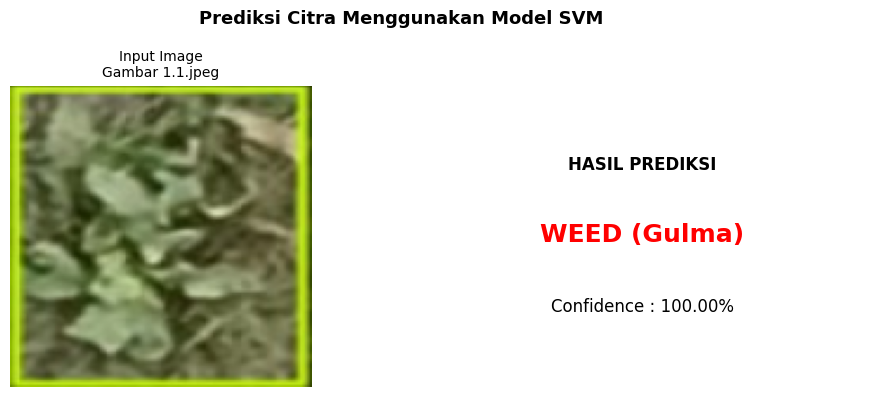

File       : Gambar 1.1.jpeg
Prediksi   : WEED (Gulma)
Confidence : 100.00%



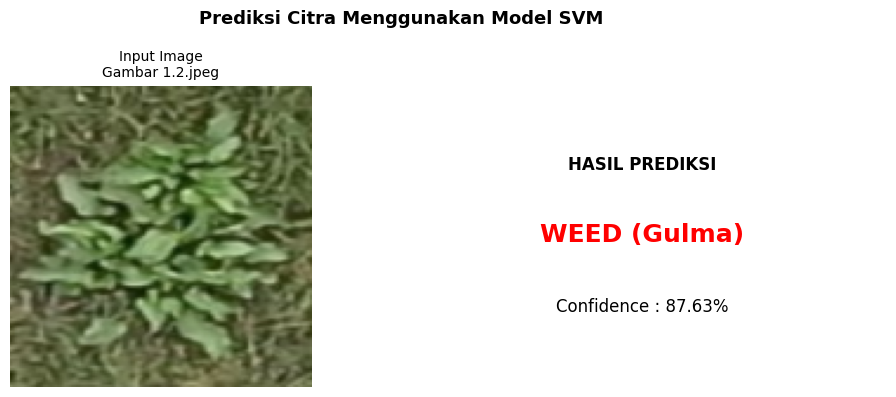

File       : Gambar 1.2.jpeg
Prediksi   : WEED (Gulma)
Confidence : 87.63%



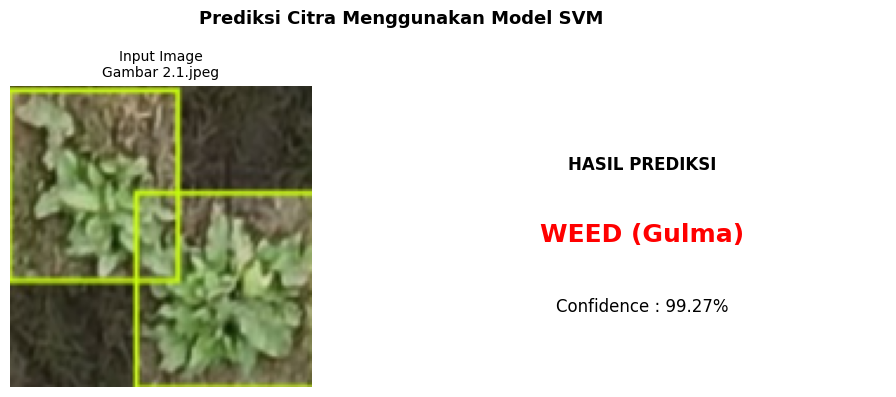

File       : Gambar 2.1.jpeg
Prediksi   : WEED (Gulma)
Confidence : 99.27%



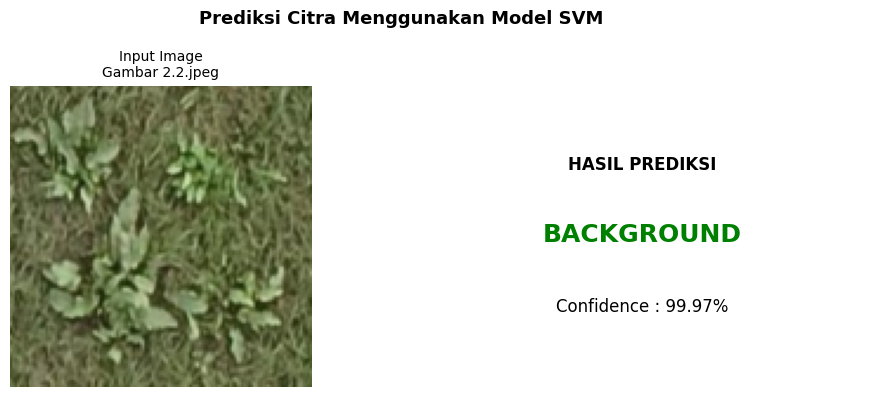

File       : Gambar 2.2.jpeg
Prediksi   : BACKGROUND
Confidence : 99.97%



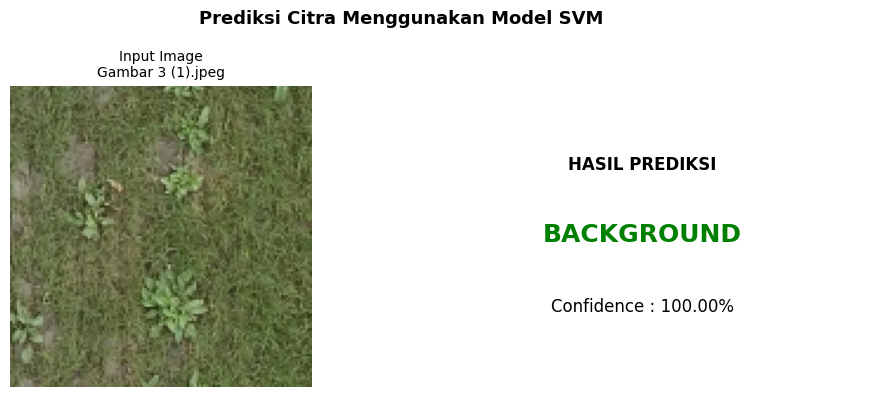

File       : Gambar 3 (1).jpeg
Prediksi   : BACKGROUND
Confidence : 100.00%



In [ ]:
# UJI CITRA BARU
from google.colab import files

print("Upload citra ROI (crop) yang ingin diuji.")
print("Citra dapat berupa gulma (weed) maupun background.\n")

uploaded = files.upload()

for filename, file_bytes in uploaded.items():

    # BACA GAMBAR
    nparr = np.frombuffer(file_bytes, np.uint8)

    img_bgr = cv2.imdecode(
        nparr,
        cv2.IMREAD_COLOR
    )

    if img_bgr is None:
        print(f"Gagal membaca file: {filename}")
        continue

    # PREPROCESSING
    resized = resize_image(img_bgr, 128)

    blurred = apply_gaussian_blur(resized)

    hsv_img = convert_rgb_to_hsv(blurred)

    gray_img = convert_rgb_to_grayscale(blurred)

    # FEATURE EXTRACTION
    hsv_feat = extract_hsv_features(
        hsv_img,
        mode=BEST_HSV_MODE
    )

    gray_q = quantize_image(
        gray_img,
        levels=BEST_GLCM["levels"]
    )

    glcm_feat = extract_glcm_features(
        gray_q,
        distance=BEST_GLCM["distance"],
        levels=BEST_GLCM["levels"]
    )

    hog_feat, _ = extract_hog_features(
        gray_img,
        orientations=BEST_HOG["orientations"],
        pixels_per_cell=BEST_HOG["pixels_per_cell"],
        cells_per_block=BEST_HOG["cells_per_block"]
    )

    # FEATURE FUSION

    fusion_feat = np.concatenate([
        hsv_feat,
        glcm_feat,
        hog_feat
    ]).reshape(1, -1)

    # NORMALISASI + PCA

    fusion_feat_scaled = scaler.transform(
        fusion_feat
    )

    fusion_feat_pca = pca.transform(
        fusion_feat_scaled
    )

    # PREDIKSI

    pred = best_svm.predict(
        fusion_feat_pca
    )[0]

    prob = best_svm.predict_proba(
        fusion_feat_pca
    )[0]

    confidence = np.max(prob) * 100

    if pred == 1:
        label_pred = "WEED (Gulma)"
        color = "red"
    else:
        label_pred = "BACKGROUND"
        color = "green"

    # VISUALISASI

    fig, axes = plt.subplots(
        1,
        2,
        figsize=(10,4)
    )

    axes[0].imshow(
        cv2.cvtColor(
            resized,
            cv2.COLOR_BGR2RGB
        )
    )

    axes[0].set_title(
        f"Input Image\n{filename}",
        fontsize=10
    )

    axes[0].axis("off")

    axes[1].axis("off")

    axes[1].text(
        0.5,
        0.72,
        "HASIL PREDIKSI",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

    axes[1].text(
        0.5,
        0.48,
        label_pred,
        ha="center",
        fontsize=18,
        fontweight="bold",
        color=color
    )

    axes[1].text(
        0.5,
        0.25,
        f"Confidence : {confidence:.2f}%",
        ha="center",
        fontsize=12
    )

    plt.suptitle(
        "Prediksi Citra Menggunakan Model SVM",
        fontsize=13,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

    # OUTPUT TEXT

    print(f"File       : {filename}")
    print(f"Prediksi   : {label_pred}")
    print(f"Confidence : {confidence:.2f}%")
    print()